In [1]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units
%matplotlib inline

In [8]:
def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level = 0.95, r2_min = 0.7):

    # Create a 1x1 grid of subplots with a more square-like figure size
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)

    # Loop through each method
    for c, method in enumerate(['FSSH']):
        taus = []
        fit_function = fitting_for_method[method]
    
        for icond in iconds:
            try:
                with h5py.File(f'{method}0_icond_{icond}/mem_data.hdf', 'r') as F:
                    sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                    md_time = np.array(F['time/data'][:]) * units.au2fs
            except FileNotFoundError:
                print(f"File not found: {method}_icond_{icond}/mem_data.hdf, skipping.")
                continue

            popt, pcov = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
            tau = popt
            residuals = sh_pop - fit_function(md_time, *popt)
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
            r_squared = 1.0 - (ss_res / ss_tot)

            print(f"icond: {icond}, r_squared: {r_squared}, tau: {tau}")  # Print r_squared for each icond

            # Only append tau and plot if r_squared is greater than 0.1        
            if r_squared > r2_min:
                ax.plot(md_time, sh_pop, color='blue', linewidth=2.0)  # Line color is black
                taus.append(tau)
                print(F"plotting this batch, the fitted tau is {tau}")
            else:
                ax.plot(md_time, sh_pop, color='grey', linewidth=2.0) 

        taus = np.array(taus)
        if len(taus) > 0:  # Proceed only if there are valid taus
            ave_tau = np.average(taus)
            s = np.std(taus)            
            N = taus.shape[0]
            #Z = 1.96 - naive value
            Z = stdtrit(N-1, conf_level) # better approach
            print(F"Z = {Z}")
            error_bar = Z * s / np.sqrt(N) 
        
            # Convert timescale to picoseconds (ps)
            ave_tau_ps = ave_tau / 1000
            error_bar_ps = error_bar / 1000
        
            print(f'The timescales for method {method}: \n {ave_tau_ps}+-{error_bar_ps} ps, averaged over {len(taus)} samples')

            ax.plot(md_time, fit_function(md_time, ave_tau - error_bar), ls='--', color="red", linewidth=2.0)
        
            # Increase the linewidth of the solid red line
            ax.plot(md_time, fit_function(md_time, ave_tau), ls='-', color="red", label=f"{method}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps \n \
$R^2$: {r2_min} confidence: {conf_level*100}%", linewidth=4)
        
            ax.plot(md_time, fit_function(md_time, ave_tau + error_bar), ls='--', color="red", linewidth=2.0)
            ax.fill_between(md_time, fit_function(md_time, ave_tau - error_bar), fit_function(md_time, ave_tau + error_bar), color='red', alpha=0.1, linewidth=2.0)

        # Set the same plot settings as before
        ax.tick_params(axis='x', labelsize=24, width=2.5, length=10)
        ax.tick_params(axis='y', labelsize=24, width=2.5, length=10)
        ax.set_xlim(left=-500, right=4001)
        ax.set_ylim(bottom=-0.001, top=0.021)
        ax.set_facecolor('white')

        for spine in ax.spines.values():
            spine.set_linewidth(2.5)

        ax.set_title(F'{figuretitle}', fontsize=26, pad=20, x=0.45)
        ax.set_xlabel('Time, fs', fontsize=26)
        ax.set_ylabel('Population', fontsize=26)

        ax.legend(fontsize=20, loc='upper left')
        fig.patch.set_facecolor('white')
        ax.set_xticks(np.arange(0, 3001, 1000))
        ax.set_ylim(0, 0.55)
        ax.set_xlim(0, 3000)
        yticks = np.linspace(0, 0.55, 5)
        #yticklabels = [f"{y:.5f}" for y in yticks]
        
        yticklabels = [f"{y:.3f}" for y in yticks]

# ===== 关键：要把它们设置到图上 =====
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=24)
        plt.tight_layout()
        plt.savefig(F'{figurename}', dpi=600)
        plt.show()

In [9]:
# Fitting functions

def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

def three_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

icond: 1, r_squared: 0.9715542352620571, tau: [3545.20425015]
plotting this batch, the fitted tau is [3545.20425015]
icond: 101, r_squared: 0.9407047003244099, tau: [3422.20479118]
plotting this batch, the fitted tau is [3422.20479118]
icond: 201, r_squared: 0.9758699280869713, tau: [3444.3374389]
plotting this batch, the fitted tau is [3444.3374389]
icond: 301, r_squared: 0.9806678957975429, tau: [3524.88676321]
plotting this batch, the fitted tau is [3524.88676321]
icond: 401, r_squared: 0.9778504971033967, tau: [3178.00136099]
plotting this batch, the fitted tau is [3178.00136099]
icond: 501, r_squared: 0.9786627344564792, tau: [3085.37129977]
plotting this batch, the fitted tau is [3085.37129977]
icond: 601, r_squared: 0.9753869347580251, tau: [3505.25266435]
plotting this batch, the fitted tau is [3505.25266435]
icond: 701, r_squared: 0.9565942514416722, tau: [3441.2569958]
plotting this batch, the fitted tau is [3441.2569958]
icond: 801, r_squared: 0.9521032443746928, tau: [3394.

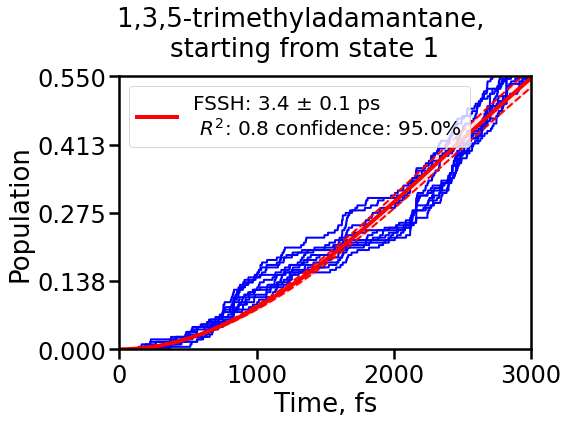

In [10]:
methods = ["FSSH"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH': three_func } 
figuretitle = "1,3,5-trimethyladamantane, \nstarting from state 1"
figurename = "FSSH-gau.png"


fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level = 0.95, r2_min = 0.8)

In [6]:
import warnings
from libra_py import trpes
%matplotlib inline
warnings.filterwarnings("ignore")  # Turn off warnings

<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWar

In [19]:
x = {"istep":5500,"fstep":7500, "dt":1.0, "namd_nsteps":2000, "units":"eV",
     "eprefix":"/vscratch/grp-alexeyak/qingxin/devel3/3/3_3methy/step2_B3LYP_new/all_logfiles/step_", "esuffix":".log",
     "input_file_type":1, "logfile_read_params": {"number_of_states":30},
     "iconds":[1, 101,201,301, 401, 501,601,701,801,901], "dprefix":"/vscratch/grp-alexeyak/qingxin/devel3/3/3_3methy/step4/s1_FSSH/FSSH0_icond_",
     "dsuffix":"/mem_data.hdf",
     "de":0.1, "emin":0.0, "emax":10, "sigma_e":0.6
    }
time_bins, energy_grid, H_total = trpes.compute_trpes(x)

{'istep': 5500, 'fstep': 7500, 'dt': 1.0, 'namd_nsteps': 2000, 'units': 'eV', 'eprefix': '/vscratch/grp-alexeyak/qingxin/devel3/3/3_3methy/step2_B3LYP_new/all_logfiles/step_', 'esuffix': '.log', 'input_file_type': 1, 'logfile_read_params': {'number_of_states': 30}, 'iconds': [1, 101, 201, 301, 401, 501, 601, 701, 801, 901], 'dprefix': '/vscratch/grp-alexeyak/qingxin/devel3/3/3_3methy/step4/s1_FSSH/FSSH0_icond_', 'dsuffix': '/mem_data.hdf', 'de': 0.1, 'emin': 0.0, 'emax': 10, 'sigma_e': 0.6}
Trajectory data contains 2000, while we only want 2000
The TRPES plot will be of the time legnth of 2000 points
The multiplication factor is 0
The shape of the effective E array is (2000, 31)
Initial iconds = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901]
Renormalizing iconds for istep = 5500, fstep = 7500 and nsteps = 2000...
The effective iconds are = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901] (dropping off meaningless iconds)
Reading the file /vscratch/grp-alexeyak/qingxin/devel3/3/3_3met

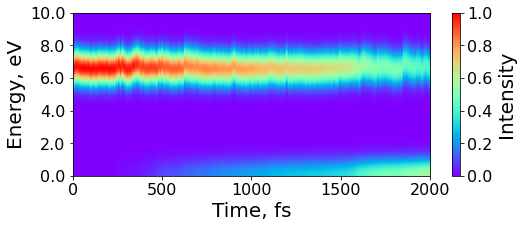

In [17]:
cmaps = ["rainbow"]

# Uniform definition of parameters to prevent warnings caused by missing default parameters
params = {
    "do_show": False,  
    "do_save": False,  
    "time_units": "fs",
    "energy_units": "eV",
    "fig_size": [8, 3],
    "cfont_size": 20,
    "ctick_size": 16,
    "xlabel_size": 20,
    "xtick_size": 16,
    "ylabel_size": 20,
    "ytick_size": 16,
    "figurename": "trpes.png",
    "dpi": 300
}

for cmap in cmaps:
    params["cmap_name"] = cmap  
    trpes.plot_trpes(time_bins, energy_grid, H_total, params)  

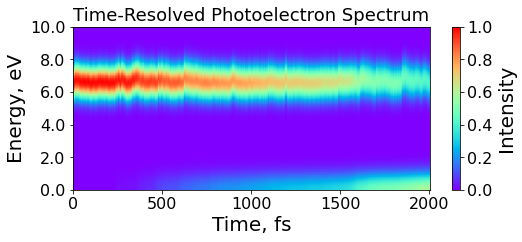

In [20]:
import matplotlib.pyplot as plt

# 绘图
trpes.plot_trpes(time_bins, energy_grid, H_total, { })

# 添加标题
plt.title("Time-Resolved Photoelectron Spectrum", fontsize=18)

# 调整 x 轴范围，比如只显示 0 到 2002 fs
plt.xlim(0, 2002)

# 保存为高清图片（白色背景、300 dpi）
plt.savefig(
    "trpes_highres.png",
    dpi=300,
    bbox_inches='tight',
    facecolor='white',      # 指定背景为白色
    transparent=False       # 禁用透明背景
)

# 显示图像
plt.show()



In [1]:
###=====================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.sparse as sp
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
from scipy.constants import physical_constants
from libra_py import trpes
import os

# ========== 全局参数 ==========
iconds = list(range(1, 1000, 100))  # ICONDS: 1,101,201,...
method = "FSSH"
color = "black"

au2ev = physical_constants["hartree-electron volt relationship"][0]
au2fs = physical_constants["atomic unit of time"][0] * 1e15

FIGSIZE = (16, 12)   # 左右两列大图
font_size = 40
tick_font = 32

# ========== TRPES 计算 ==========
x = {
    "istep": 8200,
    "fstep": 11200,
    "dt": 1.0,
    "namd_nsteps": 3000,
    "units": "eV",
    "eprefix": "/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step2_B3LYP/all_logfiles/step_",
    "esuffix": ".log",
    "input_file_type": 1,
    "logfile_read_params": {"number_of_states": 30},
    "iconds": iconds,
    "dprefix": "/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step4/s1_FSSH/FSSH0_icond_",
    "dsuffix": "/mem_data.hdf",
    "de": 0.1,
    "emin": 0.0,
    "emax": 10.0,
    "sigma_e": 0.6,
}

time_bins, energy_grid, H_total = trpes.compute_trpes(x)

# ========== 拟合函数（高斯型弛豫）==========
def refined_func(t, tau, E0, E1):
    return (E0 - E1) * np.exp(-(t / tau) ** 2) + E1

# ========== 读取绝热能量（Hvib 对角元）==========
energies = []
Hvib_path = "/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step33_nthree_B3LYP_new"
for step in range(8200, 11200):
    hv_file = f"{Hvib_path}/Hvib_ci_{step}_re.npz"
    hvib = sp.load_npz(hv_file).todense().real
    energies.append(np.diag(hvib))

energies = np.array(energies)   # (nsteps, nstates)
energies = au2ev * energies
adiabatic_energies = energies
e2 = energies

# ========== 计算每条轨迹的 excess energy 并拟合 tau ==========
all_excess_energies = []
taus = []
time_ref = None

for icond in iconds:
    h5_path = f"/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step4/s1_FSSH/{method}0_icond_{icond}/mem_data.hdf"
    try:
        with h5py.File(h5_path, "r") as F:
            sh_pop = np.array(F["sh_pop_adi/data"])          # (nsteps, nstates)
            time = np.array(F["time/data"])[0:3000] * au2fs  # fs

        if time_ref is None:
            time_ref = time

        tmp2 = np.roll(e2[0:3000, :], -icond, axis=0)
        tmp1 = sh_pop[0:3000, :] * tmp2
        tmp = np.sum(tmp1, axis=1)

        all_excess_energies.append(tmp)

        E0 = tmp[0]
        E1 = adiabatic_energies[:, 1].mean()

        popt, _ = curve_fit(
            lambda t, tau: refined_func(t, tau, E0, E1),
            time,
            tmp,
            maxfev=10000,
        )
        taus.append(popt[0])

    except Exception as e:
        print(f"[WARN] icond {icond} 出错: {e}")

if len(all_excess_energies) == 0:
    raise RuntimeError("没有成功读取到任何轨迹的 excess energy，请检查路径和文件。")

avg_excess_energy = np.mean(all_excess_energies, axis=0)

# ========== 构建“去蓝紫”的彩虹色图 ==========
base_cmap = plt.cm.get_cmap("coolwarm")
colors = base_cmap(np.linspace(0.0, 1.0, 256))
cmap_no_blue_purple = ListedColormap(colors)

# ========== 右边要用的 DOS + UV-VIS 数据 ==========
energy_levels = []
for step in range(8200, 11200):
    file_path = f"{Hvib_path}/Hvib_ci_{step}_re.npz"
    if os.path.exists(file_path):
        Hvib = sp.load_npz(file_path).todense().real
        diag_energies = np.diag(Hvib) * au2ev
        energy_levels.extend(diag_energies)

energy_levels = np.array(energy_levels)

uvvis_path = "3.txt"
x_spec, y_spec = [], []
with open(uvvis_path, "r") as f:
    for line in f:
        if line.strip():
            parts = line.split()
            x_spec.append(float(parts[0]))
            y_spec.append(float(parts[1]))

x_spec = np.array(x_spec)
y_spec = np.array(y_spec)

# ========== 画在同一张 figure 上：左右两列，sharey 硬锁 y 轴 ==========
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=FIGSIZE,
    sharey=True,
    gridspec_kw={"wspace": 0.15}
)

# ---------- 左：TRPES ----------
extent = [time_bins[0], time_bins[-1], energy_grid[0], energy_grid[-1]]

im = ax1.imshow(
    H_total.T,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap=cmap_no_blue_purple,
)

ax1.plot(
    time_ref[:len(avg_excess_energy)],
    avg_excess_energy,
    color=color,
    linewidth=3,
)

ax1.set_xlim(0, 3000)
ax1.set_xticks(np.arange(0, 3001, 1000))

ax1.set_ylim(0, 10)
ax1.set_ylabel("Energy (eV)", fontsize=font_size)
ax1.set_xlabel("Time (fs)", fontsize=font_size)
ax1.tick_params(axis="x", labelsize=tick_font, pad=15)
ax1.tick_params(axis="y", labelsize=tick_font, pad=15)

# 给左图加 colorbar（只占左 panel）
cbar = fig.colorbar(im, ax=ax1, pad=0.02)
cbar.set_label("Population", fontsize=font_size, labelpad=15)
cbar.ax.tick_params(labelsize=tick_font)

# ---------- 右：DOS + UV-VIS ----------
hist_values, bins, _ = ax2.hist(
    energy_levels,
    bins=50,
    density=True,
    orientation="horizontal",
    color="gray",
    edgecolor="black",
    alpha=0.7,
)

max_hist_value = hist_values.max()
scaling_factor = max_hist_value / max(y_spec)
y_norm = y_spec * scaling_factor

ax2.plot(
    y_norm,
    x_spec,
    linestyle="-",
    color="red",
    linewidth=3,
    label="UV-VIS",
)

ax2.set_ylim(0, 10)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)
ax2.tick_params(axis="x", labelsize=tick_font, pad=15)
ax2.legend(fontsize=28, loc="upper right")
ax2.set_xlabel("DOS", fontsize=font_size)
# ========== 先统一整体边距 ==========
fig.subplots_adjust(left=0.10, right=0.95, bottom=0.12, top=0.96)

# ========== 再单独把右图轻微右移一点 ==========
pos = ax2.get_position()
# 可以微调 shift 和 width_factor 的数值
shift = 0.03          # 往右移一点点
width_factor = 0.97    # 稍微变瘦一点，避免碰到右边界
new_x0 = pos.x0 + shift
new_width = pos.width * width_factor
ax2.set_position([new_x0, pos.y0, new_width, pos.height])

fig.savefig("TRPES_DOS_UVVIS_2methy_combinedcoolwarmttt.png",  facecolor='white',dpi=300)
plt.show()

{'istep': 8200, 'fstep': 11200, 'dt': 1.0, 'namd_nsteps': 3000, 'units': 'eV', 'eprefix': '/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step2_B3LYP/all_logfiles/step_', 'esuffix': '.log', 'input_file_type': 1, 'logfile_read_params': {'number_of_states': 30}, 'iconds': [1, 101, 201, 301, 401, 501, 601, 701, 801, 901], 'dprefix': '/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step4/s1_FSSH/FSSH0_icond_', 'dsuffix': '/mem_data.hdf', 'de': 0.1, 'emin': 0.0, 'emax': 10.0, 'sigma_e': 0.6}
Trajectory data contains 3000, while we only want 3000
The TRPES plot will be of the time legnth of 3000 points
The multiplication factor is 0
The shape of the effective E array is (3000, 31)
Initial iconds = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901]
Renormalizing iconds for istep = 8200, fstep = 11200 and nsteps = 3000...
The effective iconds are = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901] (dropping off meaningless iconds)
Reading the file /vscratch/grp-alexeyak/qingxin/3_met

In [1]:
###=====================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.sparse as sp
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
from scipy.constants import physical_constants
from libra_py import trpes
import os

# ========== 全局参数 ==========
iconds = list(range(1, 1000, 100))  # ICONDS: 1,101,201,...
method = "FSSH"
color = "black"

au2ev = physical_constants["hartree-electron volt relationship"][0]
au2fs = physical_constants["atomic unit of time"][0] * 1e15

FIGSIZE = (16, 12)   # 左右两列大图
font_size = 40
tick_font = 32

# ========== TRPES 计算 ==========
x = {
    "istep": 8200,
    "fstep": 11200,
    "dt": 1.0,
    "namd_nsteps": 3000,
    "units": "eV",
    "eprefix": "/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step2_B3LYP/all_logfiles/step_",
    "esuffix": ".log",
    "input_file_type": 1,
    "logfile_read_params": {"number_of_states": 30},
    "iconds": iconds,
    "dprefix": "/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step4/s1_FSSH/FSSH0_icond_",
    "dsuffix": "/mem_data.hdf",
    "de": 0.1,
    "emin": 0.0,
    "emax": 9.0,
    "sigma_e": 0.6,
}

time_bins, energy_grid, H_total = trpes.compute_trpes(x)

# ========== 拟合函数（高斯型弛豫）==========
def refined_func(t, tau, E0, E1):
    return (E0 - E1) * np.exp(-(t / tau) ** 2) + E1

# ========== 读取绝热能量（Hvib 对角元）==========
energies = []
Hvib_path = "/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step33_nthree_B3LYP_new"
for step in range(8200, 11200):
    hv_file = f"{Hvib_path}/Hvib_ci_{step}_re.npz"
    hvib = sp.load_npz(hv_file).todense().real
    energies.append(np.diag(hvib))

energies = np.array(energies)   # (nsteps, nstates)
energies = au2ev * energies
adiabatic_energies = energies
e2 = energies

# ========== 计算每条轨迹的 excess energy 并拟合 tau ==========
all_excess_energies = []
taus = []
time_ref = None

for icond in iconds:
    h5_path = f"/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step4/s1_FSSH/{method}0_icond_{icond}/mem_data.hdf"
    try:
        with h5py.File(h5_path, "r") as F:
            sh_pop = np.array(F["sh_pop_adi/data"])          # (nsteps, nstates)
            time = np.array(F["time/data"])[0:3000] * au2fs  # fs

        if time_ref is None:
            time_ref = time

        tmp2 = np.roll(e2[0:3000, :], -icond, axis=0)
        tmp1 = sh_pop[0:3000, :] * tmp2
        tmp = np.sum(tmp1, axis=1)

        all_excess_energies.append(tmp)

        E0 = tmp[0]
        E1 = adiabatic_energies[:, 1].mean()

        popt, _ = curve_fit(
            lambda t, tau: refined_func(t, tau, E0, E1),
            time,
            tmp,
            maxfev=10000,
        )
        taus.append(popt[0])

    except Exception as e:
        print(f"[WARN] icond {icond} 出错: {e}")

if len(all_excess_energies) == 0:
    raise RuntimeError("没有成功读取到任何轨迹的 excess energy，请检查路径和文件。")

avg_excess_energy = np.mean(all_excess_energies, axis=0)

# ========== 构建“去蓝紫”的彩虹色图 ==========
base_cmap = plt.cm.get_cmap("coolwarm")
colors = base_cmap(np.linspace(0.0, 1.0, 256))
cmap_no_blue_purple = ListedColormap(colors)

# ========== 右边要用的 DOS + UV-VIS 数据 ==========
energy_levels = []
for step in range(8200, 11200):
    file_path = f"{Hvib_path}/Hvib_ci_{step}_re.npz"
    if os.path.exists(file_path):
        Hvib = sp.load_npz(file_path).todense().real
        diag_energies = np.diag(Hvib) * au2ev
        energy_levels.extend(diag_energies)

energy_levels = np.array(energy_levels)

uvvis_path = "3.txt"
x_spec, y_spec = [], []
with open(uvvis_path, "r") as f:
    for line in f:
        if line.strip():
            parts = line.split()
            x_spec.append(float(parts[0]))
            y_spec.append(float(parts[1]))

x_spec = np.array(x_spec)
y_spec = np.array(y_spec)

# ========== 画在同一张 figure 上：左右两列，sharey 硬锁 y 轴 ==========
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=FIGSIZE,
    sharey=True,
    gridspec_kw={"wspace": 0.15}
)

# ---------- 左：TRPES ----------
extent = [time_bins[0], time_bins[-1], energy_grid[0], energy_grid[-1]]

im = ax1.imshow(
    H_total.T,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap=cmap_no_blue_purple,
)

ax1.plot(
    time_ref[:len(avg_excess_energy)],
    avg_excess_energy,
    color=color,
    linewidth=3,
)

ax1.set_xlim(0, 3000)
ax1.set_xticks(np.arange(0, 3001, 1000))

ax1.set_ylim(0, 10)
ax1.set_ylabel("Energy (eV)", fontsize=font_size)

ax1.tick_params(axis="x", labelsize=tick_font, pad=15)
ax1.tick_params(axis="y", labelsize=tick_font, pad=15)

# 给左图加 colorbar（只占左 panel）
cbar = fig.colorbar(im, ax=ax1, pad=0.02)
cbar.set_label("Population", fontsize=font_size, labelpad=15)
cbar.ax.tick_params(labelsize=tick_font)

# ---------- 右：DOS + UV-VIS ----------
hist_values, bins, _ = ax2.hist(
    energy_levels,
    bins=50,
    density=True,
    orientation="horizontal",
    color="gray",
    edgecolor="black",
    alpha=0.7,
)

max_hist_value = hist_values.max()
scaling_factor = max_hist_value / max(y_spec)
y_norm = y_spec * scaling_factor

ax2.plot(
    y_norm,
    x_spec,
    linestyle="-",
    color="red",
    linewidth=3,
    label="UV-VIS",
)

ax2.set_ylim(0, 10)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)
ax2.tick_params(axis="x", labelsize=tick_font, pad=15)
ax2.legend(fontsize=28, loc="upper right")

# ========== 先统一整体边距 ==========
fig.subplots_adjust(left=0.10, right=0.95, bottom=0.12, top=0.96)

# ========== 再单独把右图轻微右移一点 ==========
pos = ax2.get_position()
# 可以微调 shift 和 width_factor 的数值
shift = 0.03          # 往右移一点点
width_factor = 0.97    # 稍微变瘦一点，避免碰到右边界
new_x0 = pos.x0 + shift
new_width = pos.width * width_factor
ax2.set_position([new_x0, pos.y0, new_width, pos.height])

fig.savefig("TRPES_DOS_UVVIS_2methy_combinedcoolwarmtt2222t.png",  facecolor='white',dpi=300)
plt.show()

{'istep': 8200, 'fstep': 11200, 'dt': 1.0, 'namd_nsteps': 3000, 'units': 'eV', 'eprefix': '/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step2_B3LYP/all_logfiles/step_', 'esuffix': '.log', 'input_file_type': 1, 'logfile_read_params': {'number_of_states': 30}, 'iconds': [1, 101, 201, 301, 401, 501, 601, 701, 801, 901], 'dprefix': '/vscratch/grp-alexeyak/qingxin/3_methy_300K_new_11_22/step4/s1_FSSH/FSSH0_icond_', 'dsuffix': '/mem_data.hdf', 'de': 0.1, 'emin': 0.0, 'emax': 9.0, 'sigma_e': 0.6}
Trajectory data contains 3000, while we only want 3000
The TRPES plot will be of the time legnth of 3000 points
The multiplication factor is 0
The shape of the effective E array is (3000, 31)
Initial iconds = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901]
Renormalizing iconds for istep = 8200, fstep = 11200 and nsteps = 3000...
The effective iconds are = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901] (dropping off meaningless iconds)
Reading the file /vscratch/grp-alexeyak/qingxin/3_meth